In [1]:
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support
from collections import Counter
import matplotlib.pyplot as plt
import re

Reproducibility

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


Load dataset

In [6]:
FILE_PATH = "three_class_dataset.csv"  
df = pd.read_csv(FILE_PATH)

print("Dataset shape:", df.shape)
print(df.head())
print(df["label"].value_counts())


Dataset shape: (243475, 7)
                                             Reviews  MedicineFor  IntakeTime  \
0  this is very effective if you can get the cove...         1749        4399   
1  actually i use the generic brand of the hour n...         1749        4400   
2  cap took minutes to open process was frustrati...         1749        4406   
3  hi everyone htpfor anxietyoctgannutaken for le...         1274        4406   
4  took ssri prozac for anxietydepression for yea...         1274        4399   

   ReviewLength  NumberOfLikes  Rating  label  
0     -1.122749      -0.545990       6      1  
1     -0.104701      -0.545990      10      2  
2      0.101196      -0.545990       1      0  
3      1.054425       6.736677      10      2  
4     -0.726206       4.288012       9      2  
label
2    139854
0     82220
1     21401
Name: count, dtype: int64


Feature Selection

In [7]:
df = df[[
    "Reviews",
    "MedicineFor",
    "IntakeTime",
    "ReviewLength",
    "NumberOfLikes",
    "label"
]].copy()

df["Reviews"] = df["Reviews"].astype(str)

Train Test Split

In [8]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df["label"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (194780, 6)
Test shape: (48695, 6)


VocaBulary building

In [9]:
def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

counter = Counter()
for text in train_df["Reviews"]:
    counter.update(tokenize(text))

MAX_VOCAB_SIZE = 40000
special_tokens = ["<PAD>", "<UNK>"]

most_common = counter.most_common(MAX_VOCAB_SIZE - len(special_tokens))
vocab = {word: idx + len(special_tokens) for idx, (word, _) in enumerate(most_common)}
vocab["<PAD>"] = 0
vocab["<UNK>"] = 1

print("Vocab size:", len(vocab))

Vocab size: 40000


Glove

In [10]:
glove_path = "glove.6B.300d.txt"   # change path if needed
embedding_index = {}

with open(glove_path, "r", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embedding_index[word] = vector

print("Loaded GloVe words:", len(embedding_index))

Loaded GloVe words: 400000


Embedding Metrix

In [11]:
EMBED_DIM = 300
embedding_matrix = np.zeros((len(vocab), EMBED_DIM))

for word, idx in vocab.items():
    if word in embedding_index:
        embedding_matrix[idx] = embedding_index[word]
    else:
        embedding_matrix[idx] = np.random.normal(scale=0.6, size=(EMBED_DIM,))

Convert Review to metrix

In [12]:
MAX_LEN = 220

def text_to_sequence(text, vocab, max_len=150):
    tokens = tokenize(text)
    seq = [vocab.get(token, vocab["<UNK>"]) for token in tokens]

    if len(seq) < max_len:
        seq = seq + [vocab["<PAD>"]] * (max_len - len(seq))
    else:
        seq = seq[:max_len]

    return seq

train_sequences = np.array([text_to_sequence(text, vocab, MAX_LEN) for text in train_df["Reviews"]])
test_sequences  = np.array([text_to_sequence(text, vocab, MAX_LEN) for text in test_df["Reviews"]])

Meta Data preparation

In [13]:
X_train_meta = train_df[["ReviewLength", "NumberOfLikes"]].values.astype(np.float32)
X_test_meta  = test_df[["ReviewLength", "NumberOfLikes"]].values.astype(np.float32)

train_medicinefor = train_df["MedicineFor"].values.astype(np.int64)
test_medicinefor  = test_df["MedicineFor"].values.astype(np.int64)

train_intaketime = train_df["IntakeTime"].values.astype(np.int64)
test_intaketime  = test_df["IntakeTime"].values.astype(np.int64)

y_train = train_df["label"].values
y_test  = test_df["label"].values

print("Train text shape:", train_sequences.shape)
print("Train numeric meta shape:", X_train_meta.shape)

Train text shape: (194780, 220)
Train numeric meta shape: (194780, 2)


Dataset Class

In [14]:
class HybridReviewDataset(Dataset):
    def __init__(self, text_sequences, meta_features, medicinefor, intaketime, labels):
        self.text_sequences = torch.tensor(text_sequences, dtype=torch.long)
        self.meta_features = torch.tensor(meta_features, dtype=torch.float32)
        self.medicinefor = torch.tensor(medicinefor, dtype=torch.long)
        self.intaketime = torch.tensor(intaketime, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.text_sequences[idx],
            self.meta_features[idx],
            self.medicinefor[idx],
            self.intaketime[idx],
            self.labels[idx]
        )

train_dataset = HybridReviewDataset(
    train_sequences,
    X_train_meta,
    train_medicinefor,
    train_intaketime,
    y_train
)

test_dataset = HybridReviewDataset(
    test_sequences,
    X_test_meta,
    test_medicinefor,
    test_intaketime,
    y_test
)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Model Building

In [15]:
class BiLSTMWithMetadata(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        output_dim,
        num_layers,
        dropout,
        medicinefor_vocab_size,
        intaketime_vocab_size,
        cat_embed_dim,
        numeric_input_dim,
        numeric_hidden_dim
    ):
        super(BiLSTMWithMetadata, self).__init__()

        # Text branch
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float32),
            freeze=False,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Categorical metadata embeddings
        self.medicinefor_embedding = nn.Embedding(medicinefor_vocab_size + 1, cat_embed_dim)
        self.intaketime_embedding = nn.Embedding(intaketime_vocab_size + 1, cat_embed_dim)

        # Numeric metadata branch
        self.numeric_fc = nn.Sequential(
            nn.Linear(numeric_input_dim, numeric_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Final fusion
        fusion_dim = hidden_dim * 2 + cat_embed_dim + cat_embed_dim + numeric_hidden_dim
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(fusion_dim, output_dim)

    def forward(self, text, meta_numeric, medicinefor, intaketime):
        # Text branch
        embedded = self.embedding(text)
        lstm_out, (hidden, cell) = self.lstm(embedded)

        forward_hidden = hidden[-2, :, :]
        backward_hidden = hidden[-1, :, :]
        text_features = torch.cat((forward_hidden, backward_hidden), dim=1)

        # Categorical branches
        medicinefor_features = self.medicinefor_embedding(medicinefor)
        intaketime_features = self.intaketime_embedding(intaketime)

        # Numeric branch
        numeric_features = self.numeric_fc(meta_numeric)

        # Combine
        combined = torch.cat(
            (text_features, medicinefor_features, intaketime_features, numeric_features),
            dim=1
        )
        combined = self.dropout(combined)

        out = self.fc(combined)
        return out

VOCAB_SIZE = len(vocab)
EMBED_DIM = 300
HIDDEN_DIM = 512
OUTPUT_DIM = 3
NUM_LAYERS = 2
DROPOUT = 0.55

MEDICINEFOR_VOCAB_SIZE = int(df["MedicineFor"].max())
INTAKETIME_VOCAB_SIZE = int(df["IntakeTime"].max())

CAT_EMBED_DIM = 32
NUMERIC_INPUT_DIM = 2
NUMERIC_HIDDEN_DIM = 32

model = BiLSTMWithMetadata(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    medicinefor_vocab_size=MEDICINEFOR_VOCAB_SIZE,
    intaketime_vocab_size=INTAKETIME_VOCAB_SIZE,
    cat_embed_dim=CAT_EMBED_DIM,
    numeric_input_dim=NUMERIC_INPUT_DIM,
    numeric_hidden_dim=NUMERIC_HIDDEN_DIM
).to(device)

print(model)


BiLSTMWithMetadata(
  (embedding): Embedding(40000, 300, padding_idx=0)
  (lstm): LSTM(300, 512, num_layers=2, batch_first=True, dropout=0.55, bidirectional=True)
  (medicinefor_embedding): Embedding(5764, 32)
  (intaketime_embedding): Embedding(4407, 32)
  (numeric_fc): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.55, inplace=False)
  )
  (dropout): Dropout(p=0.55, inplace=False)
  (fc): Linear(in_features=1120, out_features=3, bias=True)
)


Optimizer

In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)

Training loop

In [17]:
EPOCHS = 3

train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0

    for text_batch, meta_batch, medicinefor_batch, intaketime_batch, labels in train_loader:
        text_batch = text_batch.to(device)
        meta_batch = meta_batch.to(device)
        medicinefor_batch = medicinefor_batch.to(device)
        intaketime_batch = intaketime_batch.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(text_batch, meta_batch, medicinefor_batch, intaketime_batch)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    running_test_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for text_batch, meta_batch, medicinefor_batch, intaketime_batch, labels in test_loader:
            text_batch = text_batch.to(device)
            meta_batch = meta_batch.to(device)
            medicinefor_batch = medicinefor_batch.to(device)
            intaketime_batch = intaketime_batch.to(device)
            labels = labels.to(device)

            outputs = model(text_batch, meta_batch, medicinefor_batch, intaketime_batch)
            loss = criterion(outputs, labels)

            running_test_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_test_loss = running_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)

    acc = accuracy_score(all_labels, all_preds)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Test Loss : {avg_test_loss:.4f}")
    print(f"Accuracy  : {acc:.4f}")
    print("-" * 40)

Epoch 1/3
Train Loss: 0.6869
Test Loss : 0.5847
Accuracy  : 0.7716
----------------------------------------
Epoch 2/3
Train Loss: 0.5524
Test Loss : 0.5477
Accuracy  : 0.7834
----------------------------------------
Epoch 3/3
Train Loss: 0.5017
Test Loss : 0.5371
Accuracy  : 0.7881
----------------------------------------


Final Evulation

In [20]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for text_batch, meta_batch, medicinefor_batch, intaketime_batch, labels in test_loader:
        text_batch = text_batch.to(device)
        meta_batch = meta_batch.to(device)
        medicinefor_batch = medicinefor_batch.to(device)
        intaketime_batch = intaketime_batch.to(device)
        labels = labels.to(device)

        outputs = model(text_batch, meta_batch, medicinefor_batch, intaketime_batch)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="weighted", zero_division=0
)

print("\nFinal Improved Hybrid BiLSTM Results")
print("Accuracy :", acc)
print("Precision:", precision)
print("Recall   :", recall)
print("F1       :", f1)

print("\nClassification Report")
print(classification_report(
    all_labels,
    all_preds,
    target_names=["negative", "neutral", "positive"],
    zero_division=0
))


Final Improved Hybrid BiLSTM Results
Accuracy : 0.7880685902043331
Precision: 0.7531110711663909
Recall   : 0.7880685902043331
F1       : 0.7562598465666271

Classification Report
              precision    recall  f1-score   support

    negative       0.78      0.74      0.76     16444
     neutral       0.35      0.04      0.07      4280
    positive       0.80      0.93      0.86     27971

    accuracy                           0.79     48695
   macro avg       0.64      0.57      0.56     48695
weighted avg       0.75      0.79      0.76     48695



Plot

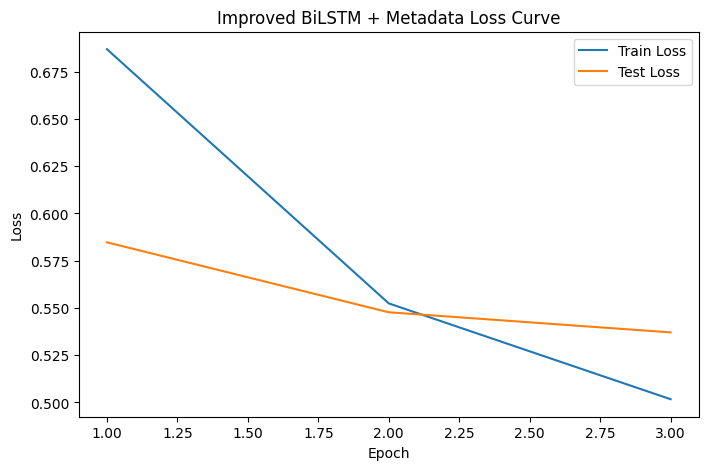

In [19]:
plt.figure(figsize=(8,5))
plt.plot(range(1, EPOCHS + 1), train_losses, label="Train Loss")
plt.plot(range(1, EPOCHS + 1), test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Improved BiLSTM + Metadata Loss Curve")
plt.legend()
plt.show()